# Mortalidad Region de Antofagasta 2017

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

###PASO 1
lee los diferentes archivos excel y los tranforma en un varaible.
Una variable es un espacio de memoria que genera en la RAM del cluod de google
La variable es `morta_antofagasta_2016` para el caso de la region de antofagasta



In [ ]:
mort_antofagasta_2016=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/muerte calama 2016.csv', header=0, delimiter=';')

###PASO 2
el siguiente codigo nos permite ver los nombres de cada columna

In [ ]:
mort_antofagasta_2016.columns.values

array(['Defunciones por algunas causas específicas de muerte (Anuario)(c',
       'Defunciones por algunas causas específicas de muerte (Anuario)',
       'sexo nombres', 'Nombres de medidas', '% de total Defunciones',
       'Valores de medidas'], dtype=object)

###PASO 3
aqui la función head() podmos ver los primeros valores dekl archivo

In [ ]:
mort_antofagasta_2016.head()

,Defunciones por algunas causas específicas de muerte (Anuario)(c,Defunciones por algunas causas específicas de muerte (Anuario),sexo nombres,Nombres de medidas,% de total Defunciones,Valores de medidas
0,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,% de total Defunciones,"33,333333333%","0,333333333"
1,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,Defunciones,"33,333333333%",4
2,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,% de total Defunciones,"66,666666667%","0,666666667"
3,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,Defunciones,"66,666666667%",8
4,C15.-,Tumor maligno del esófago,Hombres,% de total Defunciones,"58,823529412%","0,588235294"


###PASO 4
si nos damos cuenta en las filas que tiene numeros pares tienen el pocentaje y en los numeros impares tiene el numero exacto de muertes durante el año 2016. Por lo tanto la información en los numeros impares nos sirve, en los pares no para esto vamos a hacer una lista...

aqui se forma una variable que nos permite hacer una lista `[]` con serie de numeros que va desde el cero hasta el 25 saltando en 2.
esta lista se guarda en una variable denominada `r`



In [ ]:
r=range(0,25,2)
r=list(r)
print(r)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]


###PASO 5
la función .drop() nos permite borrar ciertos datos desde nuestro archivo excel. como queremos borrar las filas con porcentajes los cuales estan en las filas impares ocupamos la variable `r`

In [ ]:
mort_antofagasta_2016=mort_antofagasta_2016.drop(r, axis=0)

###PASO 6
Tambien queremos borrar las columnas que nos sirven su información y nos hace ruido para analizar el archivo excel para esto nuevamente ocupamos la función `.drop()` y dentro de esta función colocamos una lista `[]` con el nombre exacto que tiene cada columna y con una coma `,` ponemos `axis=1` para indicar a python que deben dentro de la lista estamos indicando el nombre de las columnas, no de las filas

In [ ]:
mort_antofagasta_2016=mort_antofagasta_2016.drop(['Defunciones por algunas causas específicas de muerte (Anuario)(c', 'sexo nombres', 'Nombres de medidas', '% de total Defunciones'], axis=1)

###PASO 7
vemos como quedov el archivo en excel, si se dan cuenta a borrado las columnas que nos sirven y nos hacen ruido

In [ ]:
mort_antofagasta_2016.head()

,Defunciones por algunas causas específicas de muerte (Anuario),Valores de medidas
1,"Tumores malignos del labio,de la cavidad bucal...",4
3,"Tumores malignos del labio,de la cavidad bucal...",8
5,Tumor maligno del esófago,10
7,Tumor maligno del esófago,7
9,Tumor maligno de la laringe,2


###PASO 8
Para mayor comodidad cambiamos el nombre de la columna que nos queda

In [ ]:
mort_antofagasta_2016=mort_antofagasta_2016.rename(columns={'Valores de medidas':'Cantidad 2016'})

###PASO 9
Transformamos los valores que estan en numeros enteros en un dato del tipo int

In [ ]:
mort_antofagasta_2016['Cantidad 2016']=mort_antofagasta_2016['Cantidad 2016'].astype(int)

###PASO 10
una vez tranformados en una variable `int` se suman cada enfermedad (vieron que la tabla de arriba se repite dos vaces cada enfermedad donde cada fila en para hombres y muejres muertos para cada enfermedad)

In [ ]:
mort_antofagasta_2016.groupby('Defunciones por algunas causas específicas de muerte (Anuario)').sum()

,Cantidad 2016
Defunciones por algunas causas específicas de muerte (Anuario),
"Bronquitis, enfisema y otras enfermedades pulmonares obstructivas crónicas",74
"Enfermedades respiratorias agudas, excepto influenza y neumonía",4
Neumonía,96
Tumor maligno de la laringe,2
"Tumor maligno de la tráquea,de los bronquios y del pulmón",192
Tumor maligno del esófago,17
"Tumores malignos del labio,de la cavidad bucal y de la faringe",12


###PASO 11
se suman todas las muertes totales por enfermedades respiratorias y se guardan en una variable `totalmort_antofagasta_2016`

In [ ]:
totalmort_antofagasta_2016=mort_antofagasta_2016['Cantidad 2016'].sum()
totalmort_antofagasta_2016

397

###PASO 12
Si la CIUDAD de Antofagasta tiene una población de 361873 habitantes se debe calcular el percapita por muerte de enfermedades respiratorias.
La mortaldiad per capita por enfermedades respiratorias se guarda en la variable `mort_percapita_antofa`




http://resultados.censo2017.cl/Region?R=R02

In [ ]:
mort_percapita_antofa=totalmort_antofagasta_2016/361.873
mort_percapita_antofa=round(mort_percapita_antofa,3)
mort_percapita_antofa
print(f'La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de {mort_percapita_antofa} N° muertes/1000 habs')

La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de 1.097 N° muertes/1000 habs


#Mortaldiad Región del BioBio 2017
recuerden cambiar una parte del nombre de la variable segun la region y repitan los 11 pasos

In [ ]:
#paso 1
mort_biobio_2016=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/muerte conce 2016.csv', header=0, delimiter=';')

In [ ]:
#paso 2
mort_biobio_2016.columns.values

array(['Defunciones por algunas causas específicas de muerte (Anuario)(c',
       'Defunciones por algunas causas específicas de muerte (Anuario)',
       'sexo nombres', 'Nombres de medidas', '% de total Defunciones',
       'Valores de medidas'], dtype=object)

In [ ]:
#paso 3
mort_biobio_2016.head()

,Defunciones por algunas causas específicas de muerte (Anuario)(c,Defunciones por algunas causas específicas de muerte (Anuario),sexo nombres,Nombres de medidas,% de total Defunciones,Valores de medidas
0,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,% de total Defunciones,"69,444444444%","0,694444444"
1,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,Defunciones,"69,444444444%",25
2,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,% de total Defunciones,"30,555555556%","0,305555556"
3,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,Defunciones,"30,555555556%",11
4,C15.-,Tumor maligno del esófago,Hombres,% de total Defunciones,"73,015873016%","0,730158730"


In [ ]:
#paso 4
r=range(0,25,2)
r=list(r)
print(r)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]


In [ ]:
#paso 5
mort_biobio_2016=mort_biobio_2016.drop(r, axis=0)

In [ ]:
#paso 6
mort_biobio_2016=mort_biobio_2016.drop(['Defunciones por algunas causas específicas de muerte (Anuario)(c', 'sexo nombres', 'Nombres de medidas', '% de total Defunciones'], axis=1)

In [ ]:
mort_biobio_2016

,Defunciones por algunas causas específicas de muerte (Anuario),Valores de medidas
1,"Tumores malignos del labio,de la cavidad bucal...",25
3,"Tumores malignos del labio,de la cavidad bucal...",11
5,Tumor maligno del esófago,92
7,Tumor maligno del esófago,34
9,Tumor maligno de la laringe,16
11,Tumor maligno de la laringe,1
13,"Tumor maligno de la tráquea,de los bronquios y...",138
15,"Tumor maligno de la tráquea,de los bronquios y...",122
17,"Enfermedades respiratorias agudas, excepto inf...",7
19,"Enfermedades respiratorias agudas, excepto inf...",14


In [ ]:
#paso 7
mort_biobio_2016=mort_biobio_2016.drop(26, axis=0)
mort_biobio_2016

,Defunciones por algunas causas específicas de muerte (Anuario),Valores de medidas
1,"Tumores malignos del labio,de la cavidad bucal...",25
3,"Tumores malignos del labio,de la cavidad bucal...",11
5,Tumor maligno del esófago,92
7,Tumor maligno del esófago,34
9,Tumor maligno de la laringe,16
11,Tumor maligno de la laringe,1
13,"Tumor maligno de la tráquea,de los bronquios y...",138
15,"Tumor maligno de la tráquea,de los bronquios y...",122
17,"Enfermedades respiratorias agudas, excepto inf...",7
19,"Enfermedades respiratorias agudas, excepto inf...",14


In [ ]:
#paso 8
mort_biobio_2016=mort_biobio_2016.rename(columns={'Valores de medidas':'Cantidad 2016'})

In [ ]:

#paso 9
mort_biobio_2016['Cantidad 2016']=mort_biobio_2016['Cantidad 2016'].astype(int)

In [ ]:
#paso 10
mort_biobio_2016.groupby('Defunciones por algunas causas específicas de muerte (Anuario)').sum()

,Cantidad 2016
Defunciones por algunas causas específicas de muerte (Anuario),
"Bronquitis, enfisema y otras enfermedades pulmonares obstructivas crónicas",334
"Enfermedades respiratorias agudas, excepto influenza y neumonía",21
Neumonía,282
Tumor maligno de la laringe,17
"Tumor maligno de la tráquea,de los bronquios y del pulmón",260
Tumor maligno del esófago,126
"Tumores malignos del labio,de la cavidad bucal y de la faringe",36


In [ ]:
#paso 11
totalmort_biobio_2016=mort_biobio_2016['Cantidad 2016'].sum()
totalmort_biobio_2016

1076

In [ ]:
#paso 12
mort_percapita_biobio=mort_biobio_2016['Cantidad 2016'].sum()/233.57
mort_percapita_biobio=round(mort_percapita_biobio,3)
mort_percapita_biobio
print(f'La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de {mort_percapita_antofa} N° muertes/1000 habs')

La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de 1.097 N° muertes/1000 habs


#Mortalidad Región de Valparaiso 2017

In [ ]:
mort_valpo_2016=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/muerte valpo 2016.csv', header=0, delimiter=';')


In [ ]:
mort_valpo_2016.columns.values

array(['Defunciones por algunas causas específicas de muerte (Anuario)(c',
       'Defunciones por algunas causas específicas de muerte (Anuario)',
       'sexo nombres', 'Nombres de medidas', '% de total Defunciones',
       'Valores de medidas'], dtype=object)

In [ ]:
mort_valpo_2016.head()

,Defunciones por algunas causas específicas de muerte (Anuario)(c,Defunciones por algunas causas específicas de muerte (Anuario),sexo nombres,Nombres de medidas,% de total Defunciones,Valores de medidas
0,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,% de total Defunciones,50%,"0,5"
1,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,Defunciones,50%,17
2,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,% de total Defunciones,50%,"0,5"
3,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,Defunciones,50%,17
4,C15.-,Tumor maligno del esófago,Hombres,% de total Defunciones,"69,090909091%","0,690909091"


In [ ]:
r=range(0,25,2)
r=list(r)
print(r)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]


In [ ]:
#paso 5
mort_valpo_2016=mort_valpo_2016.drop(r, axis=0)

In [ ]:
#paso 6
mort_valpo_2016=mort_valpo_2016.drop(['Defunciones por algunas causas específicas de muerte (Anuario)(c', 'sexo nombres', 'Nombres de medidas', '% de total Defunciones'], axis=1)

In [ ]:
#paso 7
mort_valpo_2016=mort_valpo_2016.drop(26, axis=0)
mort_valpo_2016

,Defunciones por algunas causas específicas de muerte (Anuario),Valores de medidas
1,"Tumores malignos del labio,de la cavidad bucal...",17
3,"Tumores malignos del labio,de la cavidad bucal...",17
5,Tumor maligno del esófago,38
7,Tumor maligno del esófago,17
9,Tumor maligno de la laringe,9
11,Tumor maligno de la laringe,2
13,"Tumor maligno de la tráquea,de los bronquios y...",243
15,"Tumor maligno de la tráquea,de los bronquios y...",153
17,"Enfermedades respiratorias agudas, excepto inf...",1
19,"Enfermedades respiratorias agudas, excepto inf...",11


In [ ]:
#paso 8
mort_valpo_2016=mort_valpo_2016.rename(columns={'Valores de medidas':'Cantidad 2016'})

In [ ]:
#paso 9
mort_valpo_2016['Cantidad 2016']=mort_valpo_2016['Cantidad 2016'].astype(int)

In [ ]:
#paso 10
mort_valpo_2016.groupby('Defunciones por algunas causas específicas de muerte (Anuario)').sum()

,Cantidad 2016
Defunciones por algunas causas específicas de muerte (Anuario),
"Bronquitis, enfisema y otras enfermedades pulmonares obstructivas crónicas",325
"Enfermedades respiratorias agudas, excepto influenza y neumonía",12
Neumonía,377
Tumor maligno de la laringe,11
"Tumor maligno de la tráquea,de los bronquios y del pulmón",396
Tumor maligno del esófago,55
"Tumores malignos del labio,de la cavidad bucal y de la faringe",34


In [ ]:
#paso 11
totalmort_valpo_2016=mort_valpo_2016['Cantidad 2016'].sum()
totalmort_valpo_2016

1210

In [ ]:
#paso 12
mort_percapita_valpo=mort_valpo_2016['Cantidad 2016'].sum()/296.655
mort_percapita_valpo=round(mort_percapita_valpo,3)
mort_percapita_valpo
print(f'La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de {mort_percapita_antofa} N° muertes/1000 habs')

La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de 1.097 N° muertes/1000 habs


#Mortalidad Región Metropolitana 2017

In [ ]:
mort_rm_2016=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/muerte santiago 2016.csv', header=0, delimiter=';')

In [ ]:
mort_rm_2016.columns.values

array(['Defunciones por algunas causas específicas de muerte (Anuario)(c',
       'Defunciones por algunas causas específicas de muerte (Anuario)',
       'sexo nombres', 'Nombres de medidas', '% de total Defunciones',
       'Valores de medidas'], dtype=object)

In [ ]:
mort_rm_2016.head()

,Defunciones por algunas causas específicas de muerte (Anuario)(c,Defunciones por algunas causas específicas de muerte (Anuario),sexo nombres,Nombres de medidas,% de total Defunciones,Valores de medidas
0,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,% de total Defunciones,"66,666666667%","0,666666667"
1,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Hombres,Defunciones,"66,666666667%",62
2,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,% de total Defunciones,"33,333333333%","0,333333333"
3,C00-C14,"Tumores malignos del labio,de la cavidad bucal...",Mujeres,Defunciones,"33,333333333%",31
4,C15.-,Tumor maligno del esófago,Hombres,% de total Defunciones,"59,638554217%","0,596385542"


In [ ]:
r=range(0,25,2)
r=list(r)
print(r)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]


In [ ]:
mort_rm_2016=mort_rm_2016.drop(r, axis=0)

In [ ]:
mort_rm_2016=mort_rm_2016.drop(['Defunciones por algunas causas específicas de muerte (Anuario)(c', 'sexo nombres', 'Nombres de medidas', '% de total Defunciones'], axis=1)

In [ ]:
mort_rm_2016=mort_rm_2016.drop(26, axis=0)
mort_rm_2016

,Defunciones por algunas causas específicas de muerte (Anuario),Valores de medidas
1,"Tumores malignos del labio,de la cavidad bucal...",62
3,"Tumores malignos del labio,de la cavidad bucal...",31
5,Tumor maligno del esófago,99
7,Tumor maligno del esófago,67
9,Tumor maligno de la laringe,37
11,Tumor maligno de la laringe,9
13,"Tumor maligno de la tráquea,de los bronquios y...",825
15,"Tumor maligno de la tráquea,de los bronquios y...",575
17,"Enfermedades respiratorias agudas, excepto inf...",11
19,"Enfermedades respiratorias agudas, excepto inf...",15


In [ ]:
mort_rm_2016=mort_rm_2016.rename(columns={'Valores de medidas':'Cantidad 2016'})

In [ ]:
#paso 9
mort_rm_2016['Cantidad 2016']=mort_rm_2016['Cantidad 2016'].astype(int)

In [ ]:
#paso 10
mort_rm_2016.groupby('Defunciones por algunas causas específicas de muerte (Anuario)').sum()

,Cantidad 2016
Defunciones por algunas causas específicas de muerte (Anuario),
"Bronquitis, enfisema y otras enfermedades pulmonares obstructivas crónicas",1228
"Enfermedades respiratorias agudas, excepto influenza y neumonía",26
Neumonía,1352
Tumor maligno de la laringe,46
"Tumor maligno de la tráquea,de los bronquios y del pulmón",1400
Tumor maligno del esófago,166
"Tumores malignos del labio,de la cavidad bucal y de la faringe",93


In [ ]:
#paso 11
totalmort_rm_2016=mort_valpo_2016['Cantidad 2016'].sum()
totalmort_rm_2016

1210

In [ ]:
#paso 12
mort_percapita_rm=mort_rm_2016['Cantidad 2016'].sum()/56140
mort_percapita_rm=round(mort_percapita_rm,3)
mort_percapita_rm
print(f'La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de {mort_percapita_rm} N° muertes/1000 habs')

La tasa percapita de mortalidad por enfermedades respieratorias por cada 100.000 habitantes es de 0.077 N° muertes/1000 habs


#Condiciones ambientales en la región de Antofagasta año 2017

###PASO 1
declaramos la variable `mp10_antofagasta2017` con el archivo excel que tiene un historico sobre las concentraciones de mp10.
se colocan todas las zonas que fueron identificadas. si se dan cuenta tiene una variable para cada excel dentro de la región de antofagasta.
Para ver el mapa e identificar las ciudades lo pueden ver por aca
https://sinca.mma.gob.cl/

In [ ]:
mp10_antofagasta2017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/Copia de antofagasta(mp10)-antofagasta.csv', header=0, delimiter=';')
#mp10_calama12017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/Copia de calama1(mp10)-antofagasta.csv', header=0, delimiter=';')
#mp10_calama22017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/Copia de calama2(mp10)-antofagasta.csv', header=0, delimiter=';')
#mp10_tocopilla12017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/tocopilla1(mp10)-arica.csv', header=0, delimiter=';')
#mp10_tocopilla22017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/tocopilla2(mp10)-arica.csv', header=0, delimiter=';')
#mp10_tocopilla32017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/tocopilla3(mp10)-arica.csv', header=0, delimiter=';')
#mp10_mejillones2017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/mejillones1(mp10)-antofagasta.csv', header=0, delimiter=';')

###PASO 2
vemos como queda la tabla

In [ ]:
mp10_antofagasta2017.head()

,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,"28,0615",NaN,NaN,NaN
1,150201,0,"36,4391",NaN,NaN,NaN
2,150301,0,"46,3722",NaN,NaN,NaN
3,150401,0,"44,9302",NaN,NaN,NaN
4,150501,0,"48,2143",NaN,NaN,NaN


###PASO 3
hay columnas que no son utiles, asi que se borran

In [ ]:
mp10_antofagasta2017=mp10_antofagasta2017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)
#mp10_calama12017=mp10_calama12017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)
#mp10_calama22017=mp10_calama22017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)
#mp10_tocopilla12017=mp10_tocopilla12017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)
#mp10_tocopilla22017=mp10_tocopilla22017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)
#mp10_tocopilla32017=mp10_tocopilla32017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)
#mp10_mejillones2017=mp10_mejillones2017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)


###PASO 4
con la función `.iloc[]` indicamos cuales son las filas que se quedan adentro de la tabla y las demas se eliminan. entre el rango de las filas desde la fila 24 hasta la 35 me indica los 12 meses del año 2017

In [ ]:
mp10_antofagasta2017=mp10_antofagasta2017.iloc[24:36]
#mp10_calama12017=mp10_calama12017.iloc[24:36]
#mp10_calama22017=mp10_calama22017.iloc[24:36]
#mp10_tocopilla12017=mp10_tocopilla12017.iloc[24:36]
#mp10_tocopilla22017=mp10_tocopilla22017.iloc[24:36]
#mp10_tocopilla32017=mp10_tocopilla32017.iloc[24:36]
#mp10_mejillones2017=mp10_mejillones2017.iloc[24:36]

vemos como queda el recorte
debe llegar con la fecha de 171201



In [ ]:
mp10_antofagasta2017

,FECHA (YYMMDD),Registros validados
24,170101,"28,4913"
25,170201,"38,7815"
26,170301,"41,3342"
27,170401,"39,5193"
28,170501,"42,1613"
29,170601,"45,2857"
30,170701,"43,1613"
31,170801,"35,7742"
32,170901,"33,3333"
33,171001,"30,4516"


In [ ]:
#mp10_tocopilla12017 no tiene datos por eso se elimina con un #
#mp10_tocopilla22017 no tiene datos por eso se elimina con un #
#mp10_tocopilla32017 no tiene datos por eso se elimina con un #
#mp10_mejillones2017 no tiene datos por eso se elimina con un #

###PASO 5
como python lee los dedcimales con . y no con , por lo tanto se debe cambiar con el siguietne ciclo for.

In [ ]:
mp10_antofagasta2017['Registros validados'] = [float(x.replace(',','.')) for x in mp10_antofagasta2017['Registros validados'] ]

###PASO 6
se obtiene la media anual de las concentración

In [ ]:
mp10_antofagasta2017_mean=mp10_antofagasta2017['Registros validados'].mean()
mp10_antofagasta2017_mean

35.76855833333334

#Condiciones ambientales en la región del Biobio año 2017

###PASO 1

In [ ]:
mp10_biobio2017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/Kingston College(mp10).csv', header=0, delimiter=';')

In [ ]:
mp10_biobio2017.head()


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,170101,0,"35,6859",NaN,NaN,NaN
1,170201,0,"38,9249",NaN,NaN,NaN
2,170301,0,"27,0171",NaN,NaN,NaN
3,170401,0,"24,2079",NaN,NaN,NaN
4,170501,0,"40,7097",NaN,NaN,NaN


###PASO 3

In [ ]:
mp10_biobio2017=mp10_biobio2017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)

###PASO 5

In [ ]:
mp10_biobio2017['Registros validados'] = [float(x.replace(',','.')) for x in mp10_biobio2017['Registros validados'] ]

###PASO 6

In [ ]:
mp10_biobio2017_mean=mp10_biobio2017['Registros validados'].mean()
mp10_biobio2017_mean

30.170833333333334

#Condiciones ambientales en la región de Valparaiso año 2017

In [ ]:
mp10_valpo2017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/vinha(mp10).csv', header=0, delimiter=';')

In [ ]:
mp10_valpo2017=mp10_valpo2017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)

In [ ]:
mp10_valpo2017['Registros validados'] = [float(x.replace(',','.')) for x in mp10_valpo2017['Registros validados'] ]

In [ ]:
mp10_valpo2017_mean=mp10_valpo2017['Registros validados'].mean()
mp10_valpo2017_mean

36.76315

#Condiciones ambientales en la región de Metropolitana año 2017

In [ ]:
mp10_RM2017=pd.read_csv('/content/drive/MyDrive/Kent/IDEC/Cancer_DataScience/datos/santiago(mp10).csv', header=0, delimiter=';')

In [ ]:
mp10_RM2017=mp10_RM2017.drop(['HORA (HHMM)','Registros preliminares', 'Registros no validados', 'Unnamed: 5'], axis=1)

In [ ]:
mp10_RM2017['Registros validados'] = [float(x.replace(',','.')) for x in mp10_RM2017['Registros validados'] ]

In [ ]:
mp10_RM2017_mean=mp10_RM2017['Registros validados'].mean()
mp10_RM2017_mean

64.441075

#Gráfico

In [ ]:
xmp10=[64.44, 36.7, 30.17, 35.76]
regiones=['RM','Valpo','Biobio','Antofagasta']
mort=[0.77, 4.79, 4.6, 1.09]
dict= {'regiones':['RM','Valpo','Biobio','Antofagasta'],
       'mp10':[64.44, 36.7, 30.17, 35.76],
       'mort':[0.77, 4.79, 4.6, 1.09]}
df = pd.DataFrame(dict)
df

,regiones,mp10,mort
0,RM,64.44,0.77
1,Valpo,36.70,4.79
2,Biobio,30.17,4.60
3,Antofagasta,35.76,1.09


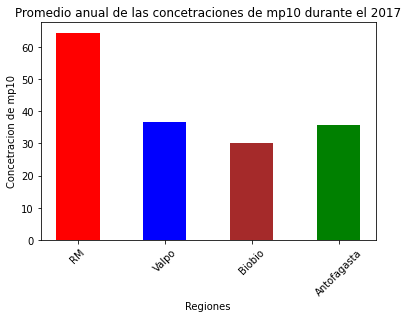

In [ ]:
plt.bar(df['regiones'], df['mp10'], width=0.5, color=['red','blue','brown','green']) #width= es el ancho de als barras, color= cambian de color intercalado
plt.xticks(np.arange(4),('RM','Valpo','Biobio','Antofagasta'), rotation=45) #np.arange(5) genera un bublce for del set de datos que viene despues indica entre () | la rotation es de 45° de las leyendas
#se agrega titulo, nombres de los ejes por parte del reto
plt.xlabel('Regiones')
plt.ylabel('Concetracion de mp10')
plt.title('Promedio anual de las concetraciones de mp10 durante el 2017')
plt.show()

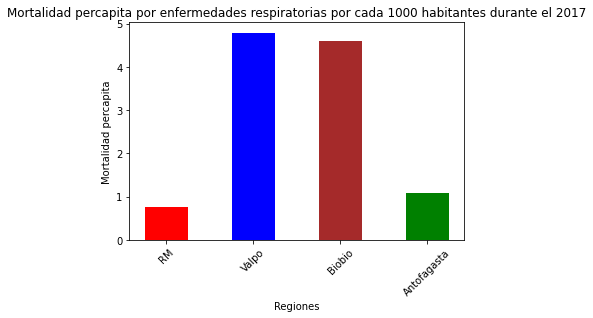

In [ ]:
plt.bar(df['regiones'], df['mort'], width=0.5, color=['red','blue','brown','green']) #width= es el ancho de als barras, color= cambian de color intercalado
plt.xticks(np.arange(4),('RM','Valpo','Biobio','Antofagasta'), rotation=45) #np.arange(5) genera un bublce for del set de datos que viene despues indica entre () | la rotation es de 45° de las leyendas
#se agrega titulo, nombres de los ejes por parte del reto
plt.xlabel('Regiones')
plt.ylabel('Mortalidad percapita')
plt.title('Mortalidad percapita por enfermedades respiratorias por cada 1000 habitantes durante el 2017')
plt.show()

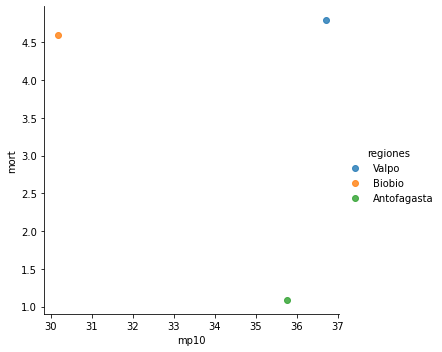

In [ ]:
sns.lmplot(x='mp10', y="mort",hue='regiones',  data=df)
plt.show()